# PoC  Clasificación de intención, extracción de entidades y enrutamiento FAQ

Este *notebook* implementa la **prueba de concepto (PoC)** del asistente de FAQs de cocina definida en la memoria. El objetivo es demostrar que el *pipeline* `[Idioma -> Intención -> Entidades]` funciona correctamente antes de conectarlo con una base de datos real de FAQs.

**Estructura**

| Sección | Tarea | Contenido |
|---------|-------|-----------|
| 1 | T1 Identificación de idioma | lingua: evaluación sobre el conjunto de test |
| 2 | T2 Clasificación de intención | Selección del clasificador (grid search), *Baseline* normalizado, TF-IDF + LinearSVC, métricas por idioma, matrices de confusión |
| 3 | Análisis de errores | Fallos y conexión con el análisis lingüístico de la Entrega 1 |
| 4 | T3 Extracción de entidades | Vía léxica (diccionarios culinarios, cobertura) + Vía semántica (`EntityExtractor`, spaCy + similitud coseno) |
| 5 | *Pipeline* completo | Función que devuelve `[Idioma, Intención, Entidades]` para cualquier consulta |
| 6 | T4 Propuesta de enrutamiento | Diseño teórico comparativo: Whoosh (léxico) vs. *embeddings* (semántico) |

**Requisito previo**

Ejecutar `Analisis_Datos_PLN.ipynb` para generar los archivos `clean_data_*.csv` en la carpeta `data/`.

In [1]:
# Si estás en Colab
# from google.colab import drive
# drive.mount ('/content/drive')
# %cd /content/drive/MyDrive/Colab Notebooks/PLN/PoC

# import pandas as pd

## Índice

1. [Identificación de idioma (T1)](#1-Identificación-de-idioma-T1)
2. [Clasificación de intención (T2)](#2-Clasificación-de-intención-T2)
   - [2.1 Selección del clasificador](#21-Selección-del-clasificador)
   - [2.2 Clasificador trivial como *baseline*](#22-Clasificador-trivial-como-baseline)
   - [2.3 Modelo TF-IDF + LinearSVC](#23-Modelo-TF-IDF--LinearSVC)
   - [2.4 Comparación de métricas por idioma](#24-Comparación-de-métricas-por-idioma)
   - [2.5 Matrices de confusión](#25-Matrices-de-confusión)
3. [Análisis de errores](#3-Análisis-de-errores)
   - [3.1 Conexión con el análisis lingüístico (Entrega 1)](#31-Conexión-con-el-análisis-lingüístico-Entrega-1)
4. [Extracción de entidades (T3)](#4-Extracción-de-entidades-T3)
   - [4.1 Vía léxica: diccionarios culinarios](#41-Vía-léxica-diccionarios-culinarios)
   - [4.2 Vía semántica: EntityExtractor (spaCy + similitud coseno)](#42-Vía-semántica-EntityExtractor)
5. [*Pipeline* completo: \[Idioma, Intención, Entidades\]](#5-Pipeline-completo-Idioma-Intención-Entidades)
   - [5.1 Ejemplos guiados (una consulta por intención)](#51-Ejemplos-guiados-una-consulta-por-intención)
   - [5.2 Casos difíciles](#52-Casos-difíciles)
6. [Propuestas de enrutamiento al FAQ (T4)](#6-Propuestas-de-enrutamiento-al-FAQ-T4)
   - [6.1 Motor de indexación Whoosh](#61-Motor-de-indexación-Whoosh)
   - [6.2 Vía semántica: *embeddings*](#62-Vía-semántica-embeddings)


In [2]:
!pip install -q lingua-language-detector spacy pyspellchecker unidecode contractions whoosh sentence-transformers # este último va fuera en un futuro
!python -m spacy download es_core_news_md -q
!python -m spacy download en_core_web_md -q

/Users/antoniommff/.zshenv:.:1: no such file or directory: /Users/antoniommff/.cargo/env
/Users/antoniommff/.zshenv:.:1: no such file or directory: /Users/antoniommff/.cargo/env
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
/Users/antoniommff/.zshenv:.:1: no such file or directory: /Users/antoniommff/.cargo/env
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [3]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
warnings.filterwarnings('ignore')

SEED = 42

data_train_en = pd.read_csv('data/clean_data_train_en.csv')
data_test_en  = pd.read_csv('data/clean_data_test_en.csv')
data_train_es = pd.read_csv('data/clean_data_train_es.csv')
data_test_es  = pd.read_csv('data/clean_data_test_es.csv')

INTENT_MAPPING = {
    'meal_suggestion': 1,
    'recipe': 2,
    'ingredients_list': 3,
    'ingredient_substitution': 4,
    'nutrition_info': 5,
    'calories': 6,
    'cook_time': 7,
    'food_last': 8,
}
REV_INTENT = {v: k for k, v in INTENT_MAPPING.items()}

print(f'Train EN: {len(data_train_en)} | Test EN: {len(data_test_en)}')
print(f'Train ES: {len(data_train_es)} | Test ES: {len(data_test_es)}')

Train EN: 960 | Test EN: 240
Train ES: 960 | Test ES: 240


## 1. Identificación de idioma (T1)

**Nuevo:** Podemos evaluar cómo de bien detectamos idioma porque lo tenemos etiquetado. Basta juntar los datos de test de ambos idiomas (hacer un shuffle porque si no están todos seguidos en inglés y español) y probar el detector de idioma de lingua sobre el conjunto de datos de test y medir la tasa de acierto. Yo diría que de forma teórica (muestral en test) va a acertar siempre y de forma práctica (producción, no evaluable) también debería a menos que hagas ahí un bilingüismo exagerado.

In [4]:
!pip install lingua-language-detector -q

/Users/antoniommff/.zshenv:.:1: no such file or directory: /Users/antoniommff/.cargo/env


In [5]:
data_language = pd.concat([data_test_en, data_test_es]).sample(frac=1, random_state=SEED)
data_language[:3]

,text,intent,intent_name,language,clean_text
73,how long does it take to cook meal of tuscan,7,cook_time,en,how long cook meal tuscan
174,Déjame saber qué ingredientes necesito para ha...,3,ingredients_list,es,dejame ingrediente necesitar hacer pasta
154,¿Qué se necesita para cocinar lasaña?,3,ingredients_list,es,necesitar cocinar lasana


In [6]:
from lingua import Language
from aux.preprocesamiento import detector

def predecir_idioma(texto):
    idioma_lingua = detector.detect_language_of(texto)
    return 'es' if idioma_lingua == Language.SPANISH else 'en'

data_language['pred'] = data_language['text'].apply(predecir_idioma)

In [7]:
accuracy = accuracy_score(data_language['language'], data_language['pred'])
print(f"Accuracy total: {accuracy:.1%}")

Accuracy total: 100.0%


El detector de idiomas funciona perfecto para todo el test.

## 2. Clasificación de intención (T2)

### 2.1 Selección del clasificador

Como paso previo a la evaluación en PoC, se exploran tres modelos clásicos sobre TF-IDF (Naive Bayes multinomial, regresión logística y LinearSVC) con validación cruzada estratificada de 5 pliegues, para seleccionar el mejor clasificador e hiperparámetros sin evaluar sobre el conjunto de test.

Debido al tamaño del conjunto de datos (960 observaciones en cada conjunto de entrenamiento), y tal como se detalla en la Entrega 2, se ha optado por mantener TF-IDF + clasificador clásico para T2.

Como clasificador, se explorarán modelos sencillos: Naive Bayes multinomial, regresión logística y máquinas de soporte vectorial. Para ello, se utilizarán las implementaciones de scikit-learn.

No podemos seleccionar el modelo y optimizar sus parámetros evaluando sobre el conjunto de test, pues no obtendríamos una evaluación honesta. Se decide por tanto emplear validación cruzada con 5 pliegues.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB


def optimize_model(df, language, ngram_range):
    """
    Entrena y optimiza modelos para un idioma y rango de n-gramas dado.
    ngram_range: tupla, ej. (1,1) unigramas, (1,2) uni+bigramas.
    Devuelve el diccionario con los GridSearchCV de cada modelo.
    """

    ngram_label = "UNIGRAMAS (1,1)" if ngram_range == (1, 1) else "UNI+BIGRAMAS (1,2)"
    print(f"\n{'='*60}")
    print(f"INICIANDO: {language.upper()} | MODO: {ngram_label}")
    print(f"{'='*60}\n")

    X = df['clean_text'].fillna('')
    y = df['intent']

    # ── PIPELINES ────────────────────────────────────────────────────────────────
    pipelines = {
        'NaiveBayes': Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=ngram_range)),
            ('clf',  MultinomialNB())
        ]),
        'SVM': Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=ngram_range)),
            ('clf',  LinearSVC(dual=False, max_iter=1000))
        ]),
        'LogReg': Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=ngram_range)),
            ('clf',  LogisticRegression(max_iter=1000))
        ])
    }

    # ── REJILLA DE HIPERPARÁMETROS ────────────────────────────────────────────────
    param_grids = {
        'NaiveBayes': {'clf__alpha': [0.1, 0.5, 1, 2, 5]},  # Suavizado de Laplace
        'SVM':        {'clf__C':     [0.1, 0.5, 1, 2, 5]},  # Margen del hiperplano separador
        'LogReg':     {'clf__C':     [0.1, 0.5, 1, 2, 5]},  # Inverso de regularización L2
    }

    # ── VALIDACIÓN CRUZADA ────────────────────────────────────────────────────────
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    best_models = {}

    for name, pipeline in pipelines.items():
        print(f"  Buscando hiperparámetros para [{name}]...")
        grid_search = GridSearchCV(pipeline, param_grids[name], cv=cv_strategy, scoring='accuracy', verbose=0)
        grid_search.fit(X, y)
        best_models[name] = grid_search
        print(f"  [{name}] Mejor accuracy: {grid_search.best_score_:.4f} | Params: {grid_search.best_params_}")

    # ── MODELO GANADOR (informativo) ──────────────────────────────────────────────
    best_name = max(best_models, key=lambda k: best_models[k].best_score_)
    print(f"\nGANADOR {language.upper()} ({ngram_label}): {best_name} (accuracy: {best_models[best_name].best_score_:.4f})\n")

    return best_models

In [9]:
# --- EJECUCION INGLÉS ---
best_models_en_1gram = optimize_model(data_train_en, "Inglés", (1, 1))
best_models_en_2gram = optimize_model(data_train_en, "Inglés", (1, 2))

# --- EJECUCION ESPAÑOL ---
best_models_es_1gram = optimize_model(data_train_es, "Español", (1, 1))
best_models_es_2gram = optimize_model(data_train_es, "Español", (1, 2))


INICIANDO: INGLÉS | MODO: UNIGRAMAS (1,1)

  Buscando hiperparámetros para [NaiveBayes]...
  [NaiveBayes] Mejor accuracy: 0.9344 | Params: {'clf__alpha': 1}
  Buscando hiperparámetros para [SVM]...
  [SVM] Mejor accuracy: 0.9604 | Params: {'clf__C': 0.5}
  Buscando hiperparámetros para [LogReg]...
  [LogReg] Mejor accuracy: 0.9573 | Params: {'clf__C': 2}

GANADOR INGLÉS (UNIGRAMAS (1,1)): SVM (accuracy: 0.9604)


INICIANDO: INGLÉS | MODO: UNI+BIGRAMAS (1,2)

  Buscando hiperparámetros para [NaiveBayes]...
  [NaiveBayes] Mejor accuracy: 0.9437 | Params: {'clf__alpha': 1}
  Buscando hiperparámetros para [SVM]...
  [SVM] Mejor accuracy: 0.9552 | Params: {'clf__C': 2}
  Buscando hiperparámetros para [LogReg]...
  [LogReg] Mejor accuracy: 0.9521 | Params: {'clf__C': 5}

GANADOR INGLÉS (UNI+BIGRAMAS (1,2)): SVM (accuracy: 0.9552)


INICIANDO: ESPAÑOL | MODO: UNIGRAMAS (1,1)

  Buscando hiperparámetros para [NaiveBayes]...
  [NaiveBayes] Mejor accuracy: 0.9385 | Params: {'clf__alpha': 0.5}
 

Los resultados son muy parecidos para los tres clasificadores, siendo ligeramente superior LinearSVC

### 2.2 Clasificador trivial como *baseline*

Con **8 clases perfectamente balanceadas**, un clasificador que asigna clases de forma aleatoria y uniforme tiene un rendimiento esperado del **12.5 %** en *accuracy*. Este es el umbral mínimo que debe superar el modelo para justificar su utilidad según los criterios de éxito de la Entrega 2.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy='uniform', random_state=SEED)

# Inglés
dummy.fit(data_train_en['clean_text'], data_train_en['intent'])
y_dummy_en = dummy.predict(data_test_en['clean_text'])
acc_dummy_en = accuracy_score(data_test_en['intent'], y_dummy_en)

# Español
dummy.fit(data_train_es['clean_text'], data_train_es['intent'])
y_dummy_es = dummy.predict(data_test_es['clean_text'])
acc_dummy_es = accuracy_score(data_test_es['intent'], y_dummy_es)

print(f'Accuracy baseline (EN): {acc_dummy_en:.1%}')
print(f'Accuracy baseline (ES): {acc_dummy_es:.1%}')
print(f'Accuracy teórica esperada (1/8 clases): 12.5%')

Accuracy baseline (EN): 12.5%
Accuracy baseline (ES): 12.5%
Accuracy teórica esperada (1/8 clases): 12.5%


### 2.3 Modelo TF-IDF + LinearSVC

Se entrena un modelo independiente por idioma. Esta arquitectura separada es coherente con la hipótesis de diseño de la Entrega 1 (T1 detecta el idioma y enruta a un módulo específico). La representación TF-IDF captura la importancia relativa de los términos discriminativos, y LinearSVC proporciona un clasificador de margen máximo robusto con pocas muestras.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

def entrenar_evaluar(train_df, test_df, lang_label, C=1):
    vectorizer = TfidfVectorizer()
    model = LinearSVC(C=C, dual=False, max_iter=1000, random_state=SEED)

    X_train = vectorizer.fit_transform(train_df['clean_text'])
    y_train = train_df['intent']
    model.fit(X_train, y_train)

    X_test = vectorizer.transform(test_df['clean_text'])
    y_test = test_df['intent']
    y_pred = model.predict(X_test)

    clases = sorted(y_test.unique())
    nombres_clases = [REV_INTENT[c] for c in clases]

    print(f'\n=== Resultados [{lang_label}] ===')
    print(classification_report(y_test, y_pred,
                                labels=clases, target_names=nombres_clases))
    return vectorizer, model, y_test, y_pred

best_C_en = best_models_en_1gram['SVM'].best_params_['clf__C']
best_C_es = best_models_es_1gram['SVM'].best_params_['clf__C']
print(f'Usando C={best_C_en} para EN y C={best_C_es} para ES (de grid search)')

vectorizer_en, model_en, y_test_en, y_pred_en = entrenar_evaluar(
    data_train_en, data_test_en, 'EN', C=best_C_en)
vectorizer_es, model_es, y_test_es, y_pred_es = entrenar_evaluar(
    data_train_es, data_test_es, 'ES', C=best_C_es)

Usando C=0.5 para EN y C=0.5 para ES (de grid search)

=== Resultados [EN] ===
                         precision    recall  f1-score   support

        meal_suggestion       0.93      0.90      0.92        30
                 recipe       0.80      0.80      0.80        30
       ingredients_list       0.93      0.83      0.88        30
ingredient_substitution       1.00      0.97      0.98        30
         nutrition_info       0.97      1.00      0.98        30
               calories       1.00      0.97      0.98        30
              cook_time       0.81      0.97      0.88        30
              food_last       1.00      0.97      0.98        30

               accuracy                           0.93       240
              macro avg       0.93      0.93      0.93       240
           weighted avg       0.93      0.93      0.93       240


=== Resultados [ES] ===
                         precision    recall  f1-score   support

        meal_suggestion       0.93      0.90   

### 2.4 Comparación de métricas por idioma

                         Modelo Accuracy EN F1 macro EN Accuracy ES F1 macro ES
Clasificador trivial (baseline)       12.5%                   12.5%            
             TF-IDF + LinearSVC       92.5%       0.925       94.2%       0.942



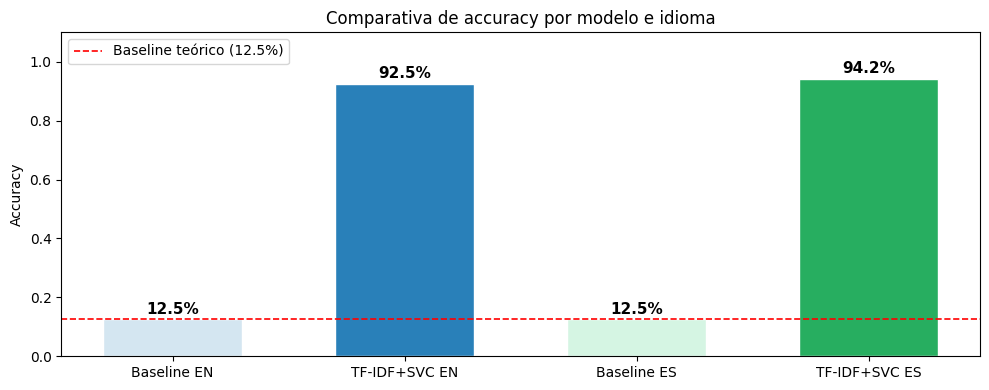

In [12]:
acc_en = accuracy_score(y_test_en, y_pred_en)
acc_es = accuracy_score(y_test_es, y_pred_es)
f1_en  = f1_score(y_test_en, y_pred_en, average='macro')
f1_es  = f1_score(y_test_es, y_pred_es, average='macro')

df_metricas = pd.DataFrame([
    {'Modelo': 'Clasificador trivial (baseline)',
     'Accuracy EN': f'{acc_dummy_en:.1%}', 'F1 macro EN': '',
     'Accuracy ES': f'{acc_dummy_es:.1%}', 'F1 macro ES': ''},
    {'Modelo': 'TF-IDF + LinearSVC',
     'Accuracy EN': f'{acc_en:.1%}', 'F1 macro EN': f'{f1_en:.3f}',
     'Accuracy ES': f'{acc_es:.1%}', 'F1 macro ES': f'{f1_es:.3f}'},
])
print(df_metricas.to_string(index=False))
print()

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 4))
categorias = ['Baseline EN', 'TF-IDF+SVC EN', 'Baseline ES', 'TF-IDF+SVC ES']
valores    = [acc_dummy_en, acc_en, acc_dummy_es, acc_es]
colores    = ['#d4e6f1', '#2980b9', '#d5f5e3', '#27ae60']
bars = ax.bar(categorias, valores, color=colores, edgecolor='white', width=0.6)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(0.125, color='red', linestyle='--', linewidth=1.2, label='Baseline teórico (12.5%)')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Comparativa de accuracy por modelo e idioma')
ax.legend()
plt.tight_layout()
plt.show()

### 2.5 Matrices de confusión

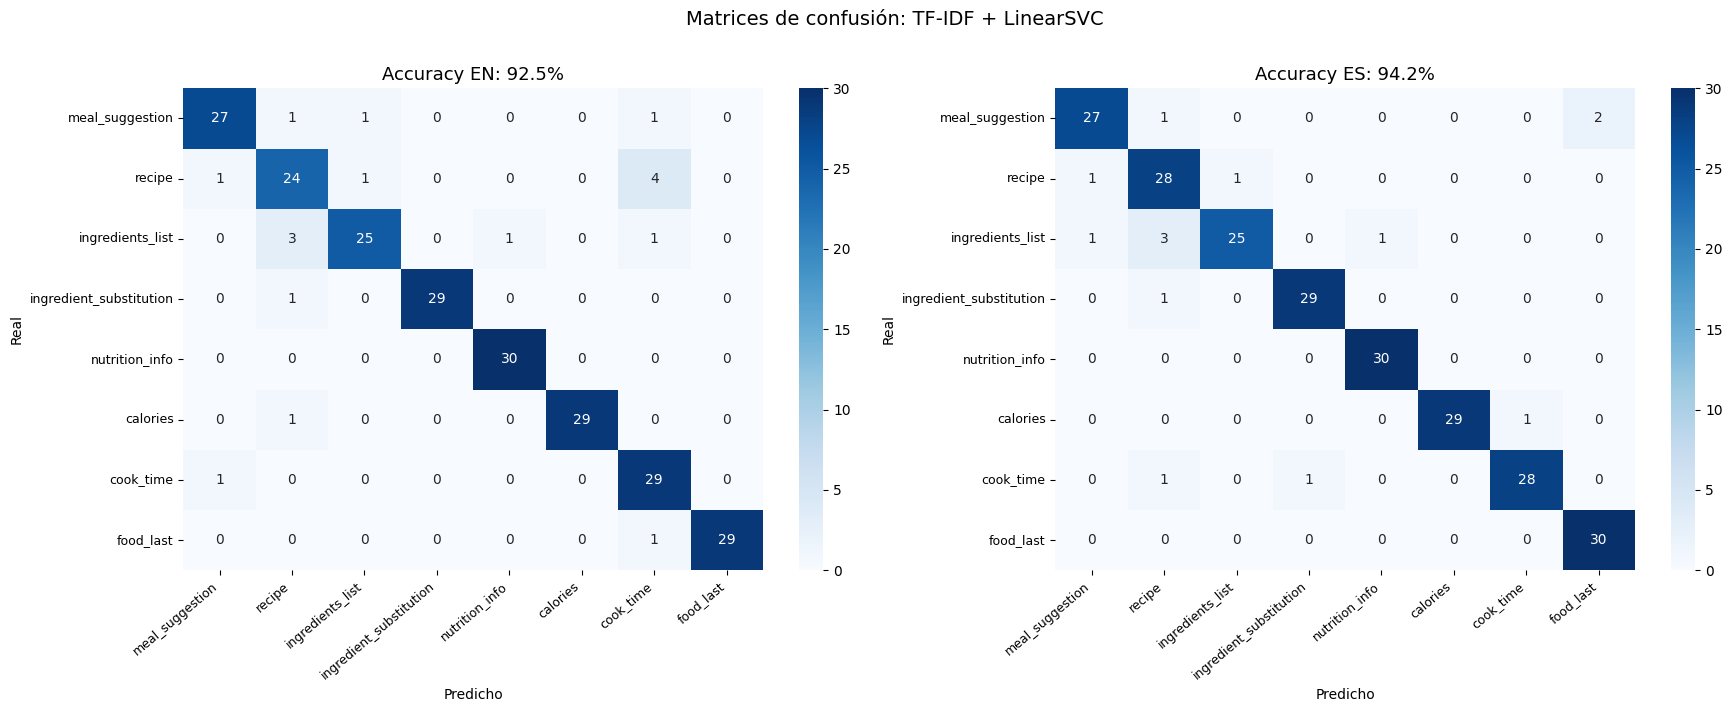

In [13]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
intent_labels = [REV_INTENT[i] for i in sorted(y_test_en.unique())]

for ax, (y_true, y_pred, titulo) in zip(axes, [
    (y_test_en, y_pred_en, f'Accuracy EN: {acc_en:.1%}'),
    (y_test_es, y_pred_es, f'Accuracy ES: {acc_es:.1%}'),
]):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax, cmap='Blues',
        xticklabels=intent_labels, yticklabels=intent_labels
    )
    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
    plt.setp(ax.get_yticklabels(), fontsize=9)

plt.suptitle('Matrices de confusión: TF-IDF + LinearSVC', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Análisis de errores

Esta sección conecta los fallos de clasificación con las dificultades lingüísticas identificadas en la **Entrega 1**, verificando empíricamente qué fenómenos predichos resultan problemáticos para el modelo.

In [14]:
def analizar_errores(test_df, y_pred, lang_label, top_n_pares=5, top_n_ejemplos=2):
    df_err = test_df.copy().reset_index(drop=True)
    df_err['y_pred']    = y_pred
    df_err['correcto']  = df_err['intent'] == df_err['y_pred']
    df_err['pred_name'] = df_err['y_pred'].map(REV_INTENT)

    errores = df_err[~df_err['correcto']].copy()
    total   = len(test_df)

    print(f'\n{'='*70}')
    print(f'ANÁLISIS DE ERRORES [{lang_label}]: {len(errores)} errores de {total} ({len(errores)/total:.1%})')
    print('='*70)

    # Pares de confusión más frecuentes
    pares = (errores
             .groupby(['intent_name', 'pred_name'])
             .size().reset_index(name='count')
             .sort_values('count', ascending=False)
             .head(top_n_pares))

    print(f'\nPares de confusión más frecuentes:')
    print(pares.to_string(index=False))

    print(f'\nEjemplos representativos por par:')
    for _, par in pares.head(3).iterrows():
        mask = ((errores['intent_name'] == par['intent_name']) &
                (errores['pred_name']   == par['pred_name']))
        ejemplos = errores[mask].head(top_n_ejemplos)
        print(f"\n  Real: '{par['intent_name']}'  Predicho: '{par['pred_name']}' (n={par['count']})")
        for _, ej in ejemplos.iterrows():
            print(f"    Texto:   {ej['text']}")
            print(f"    Limpio:  {ej['clean_text']}")

    return errores

errores_en = analizar_errores(data_test_en, y_pred_en, 'EN', 6)
errores_es = analizar_errores(data_test_es, y_pred_es, 'ES', 6)


ANÁLISIS DE ERRORES [EN]: 18 errores de 240 (7.5%)

Pares de confusión más frecuentes:
            intent_name       pred_name  count
                 recipe       cook_time      4
       ingredients_list          recipe      3
               calories          recipe      1
              cook_time meal_suggestion      1
              food_last       cook_time      1
ingredient_substitution          recipe      1

Ejemplos representativos por par:

  Real: 'recipe'  Predicho: 'cook_time' (n=4)
    Texto:   what do i need to do to cook a chicken
    Limpio:  need cook chicken
    Texto:   how do i go about cooking a 10lb turkey
    Limpio:  how cook 10 lb turkey

  Real: 'ingredients_list'  Predicho: 'recipe' (n=3)
    Texto:   give me a recipe for tacos
    Limpio:  recipe taco
    Texto:   what's a good recipe foe tacos
    Limpio:  good recipe foe taco

  Real: 'calories'  Predicho: 'recipe' (n=1)
    Texto:   how much is alorie intake
    Limpio:  how alorie intake

ANÁLISIS DE ERRO

### 3.1 Conexión con el análisis lingüístico (Entrega 1)

Los errores observados muestran las dificultades identificadas en la caracterización lingüística.

| Fenómeno | Ejemplo de fallo observado | Ejemplo del dataset |
|---------------------|---------------------------|---------------------------|
| **Ambigüedad semántica** | *"is it healthy to eat pizza"* (nutrición, no calorías) | `nutrition_info` <-> `calories` |
| **Petición implícita / pragmática** | *"how healthy is X"* puede pedir info nutricional o calorías | `nutrition_info` <-> `calories` |
| **Solapamiento léxico entre clases** | *recipe* y *ingredients_list* comparten tokens como `make`, `how` | `recipe` <-> `ingredients_list` |


El mayor número de confusiones entre `nutrition_info` y `calories` es coherente con el diagnóstico de **ambigüedad pragmática**: tanto *"how healthy is X"* como *"how many calories in X"* buscan información sobre salud/nutrición, pero el modelo debe inferir el nivel de detalle que espera el usuario.

La confusión `recipe` <-> `ingredients_list` refleja el solapamiento léxico señalado en el análisis: ambas intenciones incluyen verbos como `make` o `prepare` y sustantivos de alimentos, lo que hace difícil distinguirlas sin capturar que `ingredients_list` siempre contiene una consulta por *qué lleva* un plato, mientras que `recipe` pregunta por *cómo hacerlo*. Un modelo TF-IDF sin información sintáctica pierde esta distinción.

## 4. Extracción de entidades (T3)

T3 contextualiza la intención detectada identificando los conceptos clave de la consulta. Se exploran dos estrategias complementarias:

| Apartado | Estrategia | Herramienta |
|----------|------------|-------------|
| 4.1 | **Vía léxica**: coincidencia exacta de tokens normalizados con diccionarios culinarios | `ENTIDADES` dict |
| 4.2 | **Vía semántica**: similitud coseno entre *word embeddings* y vectores ancla por categoría | `EntityExtractor` (spaCy) |


### 4.1 Vía léxica: diccionarios culinarios

Vocabulario controlado con siete categorías semánticas. La detección se basa en intersección exacta de tokens normalizados.

In [15]:
from aux.entidades import ENTIDADES, extraer_entidades

print('Diccionarios culinarios cargados.')
for cat, dic in ENTIDADES.items():
    print(f'  {cat}: {len(dic["es"])} términos ES | {len(dic["en"])} términos EN')

Diccionarios culinarios cargados.
  ingredientes: 79 términos ES | 79 términos EN
  tecnicas: 36 términos ES | 36 términos EN
  utensilios: 27 términos ES | 27 términos EN
  dietas: 15 términos ES | 15 términos EN
  paises: 18 términos ES | 18 términos EN
  gentilicios: 18 términos ES | 18 términos EN
  platos_completos: 38 términos ES | 38 términos EN


In [16]:
# Demostración de extracción de entidades
ejemplos_entidades = [
    ('como freir pollo en sarten con ajo', 'es'),
    ('quiero hornear pasta con queso y tomate en molde', 'es'),
    ('how long to bake salmon in the oven', 'en'),
    ('can i substitute butter with olive oil in a cake recipe', 'en'),
    ('cuanto tiempo tarda en hervir el arroz en olla', 'es'),
    ('give me ingredients for garlic chicken', 'en'),
    ('querer comida frances casera', 'es')
]

print('EXTRACCIÓN DE ENTIDADES (T3)\n' + '='*60)
for texto, lang in ejemplos_entidades:
    entidades = extraer_entidades(texto, lang)
    print(f'\n[{lang.upper()}] {texto}')
    if entidades:
        for cat, vals in entidades.items():
            print(f'  {cat:15s}: {vals}')
    else:
        print('  (sin entidades detectadas)')

EXTRACCIÓN DE ENTIDADES (T3)

[ES] como freir pollo en sarten con ajo
  ingredientes   : ['ajo', 'pollo']
  tecnicas       : ['freir']
  utensilios     : ['sarten']

[ES] quiero hornear pasta con queso y tomate en molde
  ingredientes   : ['pasta', 'queso', 'tomate']
  tecnicas       : ['hornear']
  utensilios     : ['molde']

[EN] how long to bake salmon in the oven
  ingredientes   : ['salmon']
  tecnicas       : ['bake']
  utensilios     : ['oven']

[EN] can i substitute butter with olive oil in a cake recipe
  ingredientes   : ['butter', 'oil']

[ES] cuanto tiempo tarda en hervir el arroz en olla
  ingredientes   : ['arroz']
  tecnicas       : ['hervir']
  utensilios     : ['olla']

[EN] give me ingredients for garlic chicken
  ingredientes   : ['chicken', 'garlic']

[ES] querer comida frances casera
  gentilicios    : ['frances']


Se observa que aunque funciona medianamente bien en algunos casos falla, y aunque es posible seguir añadiendo y añadiendo palabras al diccionario *ad infinitum*, no es una opción razonable.

En el siguiente ejemplo buscariamos que nos devolviera "casera"
```
[ES] querer comida frances casera
  gentilicios    : ['frances']
```



#### Evaluación de la cobertura

Qué porcentaje de consultas de test tiene al menos una entidad reconocida por el diccionario.

In [17]:
# Cobertura: qué porcentaje de ejemplos del test tiene al menos una entidad extraída
for lang_label, test_df, lang_code in [
    ('EN', data_test_en, 'en'),
    ('ES', data_test_es, 'es'),
]:
    test_df['entidades'] = test_df['clean_text'].apply(
        lambda x: extraer_entidades(str(x), lang_code))
    test_df['n_entidades'] = test_df['entidades'].apply(
        lambda d: sum(len(v) for v in d.values()))
    cobertura = (test_df['n_entidades'] > 0).mean()

    print(f'[{lang_label}] Cobertura de entidades en test: {cobertura:.1%}')
    print(f'  Media de entidades por consulta: {test_df["n_entidades"].mean():.2f}')
    print(f'  Consultas sin entidades: {(test_df["n_entidades"] == 0).sum()}')
    print()

# Cobertura por intención en inglés
print('Cobertura por intención (EN):')
cob_intencion = data_test_en.groupby('intent_name')['n_entidades'].agg(
    media='mean', con_entidades=lambda x: (x > 0).sum(), total='count')
cob_intencion['%_cobertura'] = (cob_intencion['con_entidades'] / cob_intencion['total'] * 100).round(1)
print(cob_intencion.sort_values('media', ascending=False).to_string())

[EN] Cobertura de entidades en test: 65.0%
  Media de entidades por consulta: 0.77
  Consultas sin entidades: 84

[ES] Cobertura de entidades en test: 57.9%
  Media de entidades por consulta: 0.67
  Consultas sin entidades: 101

Cobertura por intención (EN):
                            media  con_entidades  total  %_cobertura
intent_name                                                         
ingredient_substitution  1.266667             26     30         86.7
cook_time                0.800000             20     30         66.7
food_last                0.800000             23     30         76.7
meal_suggestion          0.766667             22     30         73.3
calories                 0.666667             15     30         50.0
nutrition_info           0.666667             17     30         56.7
recipe                   0.633333             16     30         53.3
ingredients_list         0.566667             17     30         56.7


### 4.2 Vía semántica: `EntityExtractor` (spaCy + similitud coseno)

Alternativa que no depende de un vocabulario cerrado: clasifica cada token por similitud coseno con *vectores ancla* representativos de cada categoría. Permite detectar palabras fuera del diccionario y manejar negaciones y sustituciones mediante análisis sintáctico.

In [18]:
from aux.entidades import EntityExtractor

In [19]:
extractor = EntityExtractor()  # carga es_core_news_md + en_core_web_md
extractor.add_vectors()           # añade los vectores ancla por defecto

# Consulta básica
text_es = "quiero hacer comida italiana para cenar que me recomiendas"
extractor.pretty_print(*extractor.extract(text_es), text_es)

# Con negación explícita
text_neg = "quiero hacer comida italiana para cenar que me recomiendas sin queso"
extractor.pretty_print(*extractor.extract(text_neg, neg=True), text_neg)

# Comparativa sobre los mismos ejemplos del apartado léxico
print('\nCOMPARATIVA - Vía semántica sobre los mismos ejemplos\n' + '='*60)
for texto, lang in ejemplos_entidades:
    extractor.pretty_print(*extractor.extract(texto, lang=lang), text=texto, lang=lang, print_all=False)



[ES] quiero hacer comida italiana para cenar que me recomiendas
  comida_base      : ['comida', 'cenar']
  origen_cultura   : ['italiano']
  tipo_dieta       : []
  ingrediente      : []
  utensilios       : []
  electrodomestico : []
  Entidades: ['comida', 'cenar', 'italiano']

[ES] quiero hacer comida italiana para cenar que me recomiendas sin queso
  comida_base      : ['comida', 'cenar']
  origen_cultura   : ['italiano']
  tipo_dieta       : []
  ingrediente      : ['NO_queso']
  utensilios       : []
  electrodomestico : []
  Entidades: ['comida', 'cenar', 'italiano', 'NO_queso']

COMPARATIVA - Vía semántica sobre los mismos ejemplos

[ES] como freir pollo en sarten con ajo
  Entidades: ['pollo', 'ajo', 'freir', 'sarten']

[ES] quiero hornear pasta con queso y tomate en molde
  Entidades: ['pasta', 'queso', 'tomate', 'hornear', 'molde']

[EN] how long to bake salmon in the oven
  Entidades: ['bake', 'salmon', 'oven']

[EN] can i substitute butter with olive oil in a cake recipe


## 5. *Pipeline* completo: `[Idioma, Intención, Entidades]`

Esta sección integra T1 (identificación de idioma), T2 (clasificación de intención) y T3 (extracción de entidades) en una función unificada de predicción que, dado el texto libre de un usuario, devuelve la tupla estructurada `[Idioma, Intención, Entidades]`.

```
Texto usuario
     │
     ▼
  T1: lingua ──────────────── idioma ('es' / 'en')
     │
     ▼
  Preprocesamiento (spaCy, lematización, normalización)
     │
     ├──▶ T2: TF-IDF + LinearSVC ──── intención (1–8)
     │
     └──▶ T3: Diccionario culinario ─ entidades {ingredientes, técnicas, utensilios}
     │
     ▼
  [Idioma, Intención, Entidades]
```

In [20]:
from aux.preprocesamiento import (
    nlp_es, nlp_en, detector, spell_es, spell_en,
    KEEP_ES, KEEP_EN, STOPWORDS_ES, STOPWORDS_EN,
    SLANG_ES, EXC_ES, EXC_EN, SYN_ES, SYN_EN,
    apply_synonyms, procesar_texto,
)

print('Pipeline de preprocesamiento cargado desde aux.preprocesamiento.')

Pipeline de preprocesamiento cargado desde aux.preprocesamiento.


In [21]:
def predecir_consulta(texto_usuario: str) -> dict:
    """Devuelve la tupla [Idioma, Intención, Entidades] para cualquier consulta."""
    if not isinstance(texto_usuario, str) or not texto_usuario.strip():
        return {'error': 'Texto vacío'}

    # T1: Detección de idioma
    idioma_lingua = detector.detect_language_of(texto_usuario)
    lang = 'es' if idioma_lingua == Language.SPANISH else 'en'

    # Preprocesamiento
    texto_limpio = procesar_texto(texto_usuario, lang=lang, is_predict=True)
    if not texto_limpio:
        return {'error': 'Texto irreconocible tras limpieza', 'idioma': lang}

    # T2: Clasificación de intención
    vectorizer = vectorizer_en if lang == 'en' else vectorizer_es
    model      = model_en      if lang == 'en' else model_es
    vector     = vectorizer.transform([texto_limpio])
    intent_num = int(model.predict(vector)[0])
    intent_name = REV_INTENT.get(intent_num, 'unknown')

    # T3: Extracción de entidades
    entidades = extraer_entidades(texto_limpio, lang)

    return {
        'texto_original': texto_usuario,
        'texto_limpio':   texto_limpio,
        'idioma':         lang,
        'intencion':      f'{intent_num} ({intent_name})',
        'entidades':      entidades,
    }

print('Función predecir_consulta() definida.')

Función predecir_consulta() definida.


### 5.1 Ejemplos guiados (una consulta por intención)

In [22]:
consultas_guiadas = [
    ('cuanto tiempo tarda en hacerse el pollo al horno',       'cook_time'),
    ('cuando se me pone malo el queso fresco',                  'food_last'),
    ('que ingredientes necesito para hacer pizza casera',       'ingredients_list'),
    ('puedo sustituir la nata por leche en esta receta',        'ingredient_substitution'),
    ('cuantas calorias tiene un trozo de tarta de chocolate',   'calories'),
    ('me gustaria hacer comida italiana para cenar que me recomiendas', 'meal_suggestion'),
    ('como hacer pasta al dente con tomate y albahaca',         'recipe'),
    ('es sano comer espinacas todos los dias',                  'nutrition_info'),
]

print('EJEMPLOS GUIADOS  Pipeline completo\n' + '='*70)
for consulta, intencion_esperada in consultas_guiadas:
    r = predecir_consulta(consulta)
    acierto = '🟢' if intencion_esperada in r.get('intencion', '') else '🔴'
    print(f'\n[{acierto}] Consulta:   {consulta}')
    print(f'    Idioma:     {r["idioma"]}')
    print(f'    Intención:  {r["intencion"]}  (esperado: {intencion_esperada})')
    print(f'    Entidades:  {r["entidades"]}')
    print(f'    Limpio:     {r["texto_limpio"]}')

EJEMPLOS GUIADOS  Pipeline completo

[🟢] Consulta:   cuanto tiempo tarda en hacerse el pollo al horno
    Idioma:     es
    Intención:  7 (cook_time)  (esperado: cook_time)
    Entidades:  {'ingredientes': ['pollo'], 'utensilios': ['horno']}
    Limpio:     cuanto tiempo tardar hacer el pollo horno

[🟢] Consulta:   cuando se me pone malo el queso fresco
    Idioma:     es
    Intención:  8 (food_last)  (esperado: food_last)
    Entidades:  {'ingredientes': ['queso']}
    Limpio:     cuando malo queso fresco

[🟢] Consulta:   que ingredientes necesito para hacer pizza casera
    Idioma:     es
    Intención:  3 (ingredients_list)  (esperado: ingredients_list)
    Entidades:  {}
    Limpio:     ingrediente necesitar hacer pizza casero

[🟢] Consulta:   puedo sustituir la nata por leche en esta receta
    Idioma:     es
    Intención:  4 (ingredient_substitution)  (esperado: ingredient_substitution)
    Entidades:  {'ingredientes': ['leche', 'nata']}
    Limpio:     sustituir nata leche re

### 5.2 Casos difíciles

## 6. Propuestas de enrutamiento al FAQ (T4)

Al no disponer de una base de datos real de FAQs, la recuperación de FAQs (T4) no puede evaluarse. En esta sección, se proponen y comparan **dos estrategias** para cruzar la tupla `[Idioma, Intención, Entidades]` con un hipotético corpus de respuestas.

### 6.1 Motor de indexación Whoosh

**Whoosh** es un motor de búsqueda de texto completo en Python que crea un índice invertido sobre las preguntas de la base de FAQs y recupera las más relevantes usando el algoritmo **BM25** (variante probabilística de TF-IDF optimizada para recuperación de información).

**Flujo propuesto:**
1. Indexar todas las preguntas de las FAQs organizadas por intención.
2. Al recibir una consulta, **filtrar** el índice a las FAQs de la intención detectada en T2  reduce el espacio de búsqueda.
3. Buscar en ese subconjunto usando los tokens del texto limpio BM25 rankea por relevancia léxica.
4. Devolver la FAQ con mayor puntuación.

In [25]:
from whoosh import index, qparser
from whoosh.filedb.filestore import RamStorage
from whoosh.query import And
from aux.faqs_demo import SCHEMA, FAQS_DEMO

# Crear e indexar en memoria
storage = RamStorage()
ix = storage.create_index(SCHEMA)
writer = ix.writer()
for faq in FAQS_DEMO:
    writer.add_document(**faq)
writer.commit()

def buscar_faq_whoosh(query_tuple: dict, top_n: int = 2) -> list:
    intent_name = query_tuple.get('intencion', '').split('(')[-1].rstrip(')')
    texto       = query_tuple.get('texto_limpio', '')

    with ix.searcher() as searcher:
        q_intent = qparser.QueryParser('intencion', ix.schema).parse(intent_name)
        q_texto  = qparser.MultifieldParser(['pregunta'], ix.schema).parse(texto)
        q_final  = And([q_intent, q_texto])
        resultados = searcher.search(q_final, limit=top_n)
        return [
            {'faq_id': r['faq_id'], 'pregunta': r['pregunta'],
             'respuesta': r['respuesta'], 'score_bm25': round(r.score, 3)}
            for r in resultados
        ]

# Demostración
print('\nDEMOSTRACIÓN - Enrutamiento Whoosh\n' + '=' * 60)
for consulta in [
    'como hacer pollo al horno',
    'cuanto tiempo se tarda en cocer arroz',
    'cuantas calorias tiene la pasta al dente',
]:
    q = predecir_consulta(consulta)
    faqs = buscar_faq_whoosh(q)
    print(f'\nConsulta: {consulta}')
    print(f'   [{q["idioma"]}] Intención: {q["intencion"]} | Entidades: {q["entidades"]}')
    if faqs:
        for f in faqs:
            print(f'  FAQ [{f["faq_id"]}] (BM25={f["score_bm25"]}) {f["pregunta"]}')
            print(f'    Respuesta: {f["respuesta"][:90]}...')
    else:
        print('  Sin resultados (la FAQ no está en el corpus demo).')
    faqs = buscar_faq_whoosh(q)
    print(f'Consulta: {consulta}')
    print(f'   [{q["idioma"]}] Intención: {q["intencion"]} | Entidades: {q["entidades"]}')
    if faqs:
        for f in faqs:
            print(f'  FAQ [{f["faq_id"]}] (BM25={f["score_bm25"]}) {f["pregunta"]}')
            print(f'    Respuesta: {f["respuesta"][:90]}...')
    else:
        print('  Sin resultados (la FAQ no está en el corpus demo).')


DEMOSTRACIÓN - Enrutamiento Whoosh

Consulta: como hacer pollo al horno
   [es] Intención: 2 (recipe) | Entidades: {'ingredientes': ['pollo'], 'utensilios': ['horno']}
  FAQ [1] (BM25=10.615) como hacer pollo al horno
    Respuesta: Precalienta el horno a 200°C, sazona el pollo con sal, pimienta y aceite, y hornéalo 45 mi...
Consulta: como hacer pollo al horno
   [es] Intención: 2 (recipe) | Entidades: {'ingredientes': ['pollo'], 'utensilios': ['horno']}
  FAQ [1] (BM25=10.615) como hacer pollo al horno
    Respuesta: Precalienta el horno a 200°C, sazona el pollo con sal, pimienta y aceite, y hornéalo 45 mi...

Consulta: cuanto tiempo se tarda en cocer arroz
   [es] Intención: 7 (cook_time) | Entidades: {'ingredientes': ['arroz'], 'tecnicas': ['cocer']}
  Sin resultados (la FAQ no está en el corpus demo).
Consulta: cuanto tiempo se tarda en cocer arroz
   [es] Intención: 7 (cook_time) | Entidades: {'ingredientes': ['arroz'], 'tecnicas': ['cocer']}
  Sin resultados (la FAQ no está en e

In [27]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('Cargando modelo de embeddings...')
modelo_emb = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Pre-calcular embeddings de las FAQs (en producción se haría offline y se almacenarían)
faqs_preguntas   = [f['pregunta']  for f in FAQS_DEMO]
faqs_respuestas  = [f['respuesta'] for f in FAQS_DEMO]
faqs_intenciones = [f['intencion'] for f in FAQS_DEMO]
embeddings_faqs  = modelo_emb.encode(faqs_preguntas, convert_to_numpy=True)
print(f'Embeddings generados: {embeddings_faqs.shape}')

def buscar_faq_semantico(query_tuple: dict, top_n: int = 2) -> list:
    intent_name   = query_tuple.get('intencion', '').split('(')[-1].rstrip(')')
    texto_usuario = query_tuple.get('texto_original', '')

    emb_query = modelo_emb.encode([texto_usuario], convert_to_numpy=True)
    sims      = cosine_similarity(emb_query, embeddings_faqs)[0]

    candidatos = [
        {'faq_id': FAQS_DEMO[i]['faq_id'], 'pregunta': faqs_preguntas[i],
         'respuesta': faqs_respuestas[i], 'coseno': round(float(sims[i]), 3)}
        for i, intencion in enumerate(faqs_intenciones)
        if intencion == intent_name
    ]
    candidatos.sort(key=lambda x: x['coseno'], reverse=True)
    return candidatos[:top_n]

# Demostración con paráfrasis
print('\nDEMOSTRACIÓN  Enrutamiento semántico (paráfrasis)\n' + '='*60)
parafraseos = [
    ('¿cuánto tarda en cocerse la pasta al punto?',  'Paráfrasis de FAQ 4 (arroz/pasta)'),
    ('tiempo de cocción del ave en el horno',         'Paráfrasis de FAQ 3 (pollo/ave)'),
    ('valor calórico de los espaguetis',              'Paráfrasis de FAQ 7 (pasta/espaguetis)'),
]
for consulta, etiqueta in parafraseos:
    q = predecir_consulta(consulta)
    faqs = buscar_faq_semantico(q)
    print(f'\n[{etiqueta}]')
    print(f'  Consulta:  {consulta}')
    print(f'  Intención: {q["intencion"]}')
    if faqs:
        for f in faqs:
            print(f'  FAQ [{f["faq_id"]}] (cos={f["coseno"]}) {f["pregunta"]}')
            print(f'    Respuesta: {f["respuesta"][:90]}...')
    else:
        print('  Sin candidatos con la intención detectada.')

Cargando modelo de embeddings...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6227.88it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings generados: (12, 384)

DEMOSTRACIÓN  Enrutamiento semántico (paráfrasis)

[Paráfrasis de FAQ 4 (arroz/pasta)]
  Consulta:  ¿cuánto tarda en cocerse la pasta al punto?
  Intención: 7 (cook_time)
  FAQ [3] (cos=0.64) cuanto tiempo tarda el pollo al horno
    Respuesta: El pollo entero tarda unos 20 min por cada 500g a 180°C (pechuga: 25-30 min a 200°C)....
  FAQ [11] (cos=0.556) how long does chicken take in the oven
    Respuesta: A whole chicken takes about 20 min per 500g at 375°F (breast: 25-30 min at 400°F)....

[Paráfrasis de FAQ 3 (pollo/ave)]
  Consulta:  tiempo de cocción del ave en el horno
  Intención: 7 (cook_time)
  FAQ [3] (cos=0.814) cuanto tiempo tarda el pollo al horno
    Respuesta: El pollo entero tarda unos 20 min por cada 500g a 180°C (pechuga: 25-30 min a 200°C)....
  FAQ [11] (cos=0.638) how long does chicken take in the oven
    Respuesta: A whole chicken takes about 20 min per 500g at 375°F (breast: 25-30 min at 400°F)....

[Paráfrasis de FAQ 7 (pasta/e

### 6.2 Vía semántica: *embeddings*